In [13]:
import whitebox
import rasterio
import numpy as np

wbt = whitebox.WhiteboxTools()

# File Paths
dem = r"D:\landslide\tehri_landslide\data\DEM\DEM_Tehri_fixed.tif"
smoothed_dem = r"D:\landslide\dem_derivatives\dem_smoothed.tif"
plan_path = r"D:\landslide\dem_derivatives\plan.tif"
profile_path = r"D:\landslide\dem_derivatives\profile.tif"
final_curv_path = r"D:\landslide\final_data\Curvature_100x.tif"

# 1. Smooth the DEM (Essential for 10m resolution)
wbt.gaussian_filter(i=dem, output=smoothed_dem, sigma=1.0)

# 2. Calculate Plan and Profile
wbt.plan_curvature(
    dem=smoothed_dem, 
    output=plan_path
)

wbt.profile_curvature(
    dem=smoothed_dem, 
    output=profile_path
)

# 3. Combine and Scale using Rasterio
with rasterio.open(plan_path) as src_plan:
    plan = src_plan.read(1)
    meta = src_plan.meta

with rasterio.open(profile_path) as src_prof:
    profile = src_prof.read(1)

# Mask NoData (Whitebox usually uses -32768 or similar for curvature)
valid_mask = (plan > -1000) & (profile > -1000)

# Create output array initialized with NoData
curvature_final = np.full(plan.shape, -9999.0, dtype="float32")

# THE CALCULATION: (Plan + Profile) * 100
# This matches the 'Uttarakhand paper' logic
curvature_final[valid_mask] = (plan[valid_mask] + profile[valid_mask])

# 4. Save the final ML-ready raster
meta.update(dtype="float32", nodata=-9999.0)
with rasterio.open(final_curv_path, "w", **meta) as dst:
    dst.write(curvature_final, 1)

print("Curvature calculation complete.")

.\whitebox_tools.exe --run="GaussianFilter" --input='D:\landslide\tehri_landslide\data\DEM\DEM_Tehri_fixed.tif' --output='D:\landslide\dem_derivatives\dem_smoothed.tif' --sigma=1.0 -v --compress_rasters=False

*****************************
* Welcome to GaussianFilter *
* Powered by WhiteboxTools  *
* www.whiteboxgeo.com       *
*****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%
Progress: 43%
Progress: 44%
Prog

In [14]:
with rasterio.open(final_curv_path) as src:
    data = src.read(1)
    data = data[data != -9999.0] # Ignore NoData
    print(f"Realistic Min: {np.min(data):.2f}")
    print(f"Realistic Max: {np.max(data):.2f}")

Realistic Min: -6.23
Realistic Max: 7.67


In [15]:
import rasterio
import numpy as np

# Load the previously calculated (Plan + Profile) * 100 raster
input_path = r"D:\landslide\final_data\Curvature_100x.tif"
output_path = r"D:\landslide\final_data\Curvature.tif"

with rasterio.open(input_path) as src:
    curv = src.read(1).astype("float32")
    meta = src.meta
    nodata = src.nodata

# 1. Isolate the real terrain values
valid_mask = (curv != nodata)
valid_values = curv[valid_mask]

# 2. Statistical Clipping (The "Paper-Ready" Step)
# This finds the 1st and 99th percentiles (e.g., roughly -55 and +55)
lower_bound, upper_bound = np.percentile(valid_values, [1, 99])
print(f"Clipping range: {lower_bound:.2f} to {upper_bound:.2f}")

# Apply the clip: anything below -55 becomes -55, anything above 55 becomes 55
curv_clipped = np.clip(curv, lower_bound, upper_bound)

# 3. Restore NoData values
curv_clipped[~valid_mask] = nodata

# 4. Save the ML-ready file
meta.update(dtype="float32", nodata=nodata)
with rasterio.open(output_path, "w", **meta) as dst:
    dst.write(curv_clipped, 1)

print("ML-ready curvature created successfully.")

Clipping range: -0.03 to 0.03
ML-ready curvature created successfully.


In [16]:
with rasterio.open(output_path) as src:
    data = src.read(1)
    data = data[data != -9999.0] # Ignore NoData
    print(f"Realistic Min: {np.min(data):.2f}")
    print(f"Realistic Max: {np.max(data):.2f}")

Realistic Min: -0.03
Realistic Max: 0.03


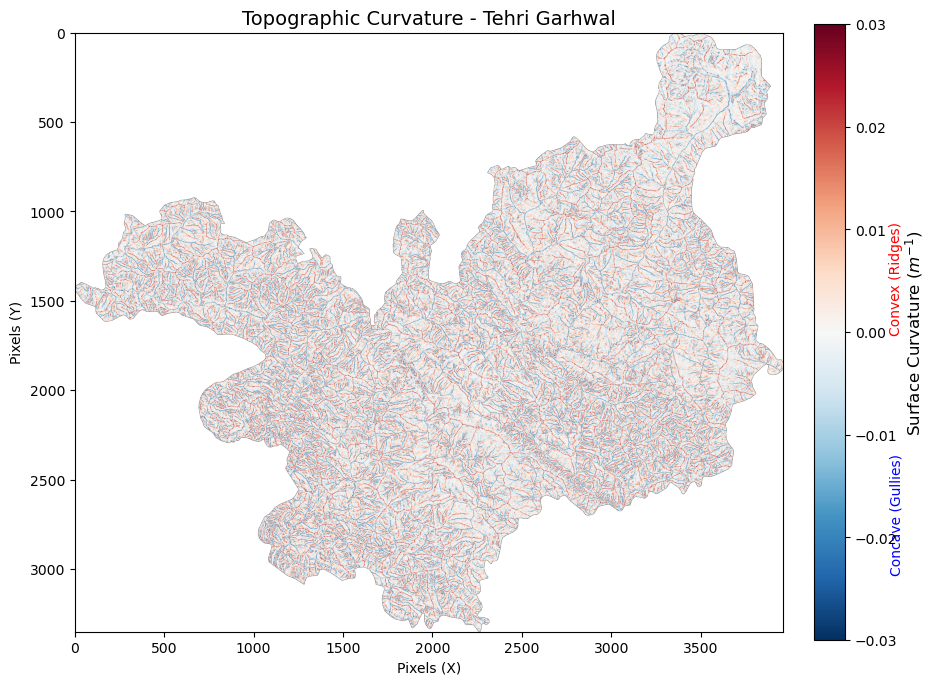

In [18]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Load your final 'True' curvature file
path = r"D:\landslide\final_data\Curvature.tif"

with rasterio.open(path) as src:
    data = src.read(1)
    # Mask out the NoData values
    nodata = src.nodata
    data = np.where(data == nodata, np.nan, data)

# 1. Set the visual limits symmetrically (e.g., -0.03 to 0.03)
# This ensures that 'White' on the map is always exactly 0 (Planar)
v_min, v_max = -0.03, 0.03 

plt.figure(figsize=(10, 8))
# 'RdBu_r' is Red-Blue reversed: Blue for Hollows, Red for Ridges
im = plt.imshow(data, cmap='RdBu_r', vmin=v_min, vmax=v_max)

# 2. Add a professional Colorbar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Surface Curvature ($m^{-1}$)', fontsize=12)

# 3. Add Labels for the Legend
plt.title("Topographic Curvature - Tehri Garhwal", fontsize=14)
plt.xlabel("Pixels (X)")
plt.ylabel("Pixels (Y)")

# Annotations to help the reader
plt.text(1.15, 0.5, 'Convex (Ridges)', transform=plt.gca().transAxes, rotation=90, color='red')
plt.text(1.15, 0.1, 'Concave (Gullies)', transform=plt.gca().transAxes, rotation=90, color='blue')

plt.savefig(r"D:\landslide\final_data\Tehri_Curvature_Plot.png", dpi=300, bbox_inches='tight')
plt.show()